# Linijinės regresijos prielaidos (model assumptions) su Python

Naudojamas pavyzdinis `tips` duomenų rinkinys iš `seaborn`. Parodomi baziniai diagnostikos žingsniai, kurie padeda įvertinti, ar daugialypės linijinės regresijos rezultatai yra patikimi interpretacijai ir prognozėms. 


In [1]:
# Bibliotekos
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Grafikai
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

# Duomenys
tips = sns.load_dataset("tips").dropna().copy()

tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Duomenys ir tikslas

`tips` rinkinys aprašo restorano sąskaitas ir arbatpinigius. Šiame pavyzdyje modeliuojamas:

- target: `tip` (arbatpinigiai)
- požymiai (features): `total_bill`, `size`, `day`, `time`, `sex`, `smoker`

Verslo interpretacijai patogu galvoti taip: `total_bill` atspindi išleistą sumą, o `tip` atspindi klientų elgseną (kiek paliekama arbatpinigių).


In [2]:
# Greita apžvalga
tips.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_bill,244.0,NaN,NaN,NaN,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,NaN,NaN,NaN,2.998279,1.383638,1.0,2.0,2.9,3.5625,10.0
sex,244,2,Male,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,244,2,No,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,244,4,Sat,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,244,2,Dinner,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,244.0,NaN,NaN,NaN,2.569672,0.9511,1.0,2.0,2.0,3.0,6.0


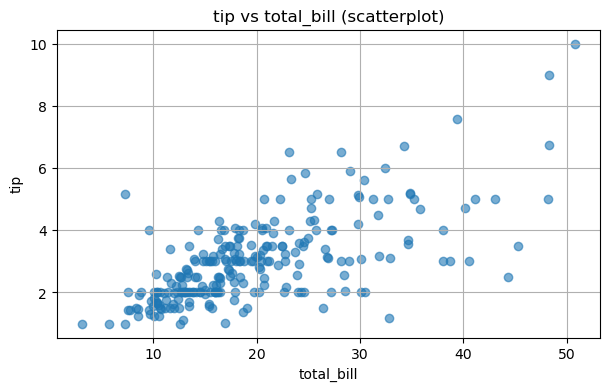

c:\Users\User\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


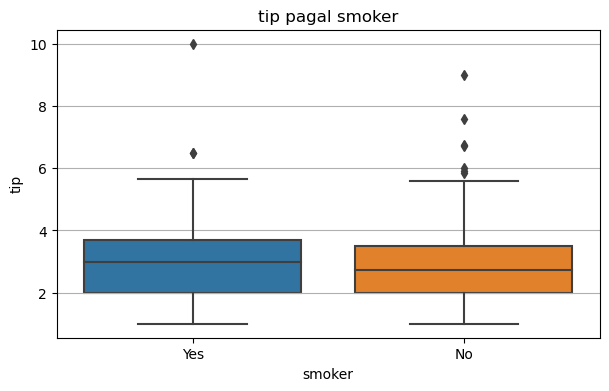

In [3]:
# Paprasti grafikai: tip ir total_bill ryšys
plt.figure()
plt.scatter(tips["total_bill"], tips["tip"], alpha=0.6)
plt.xlabel("total_bill")
plt.ylabel("tip")
plt.title("tip vs total_bill (scatterplot)")
plt.show()

# Kategoriniai pjūviai (pvz. pagal rūkymą)
plt.figure()
sns.boxplot(data=tips, x="smoker", y="tip")
plt.title("tip pagal smoker")
plt.show()


c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


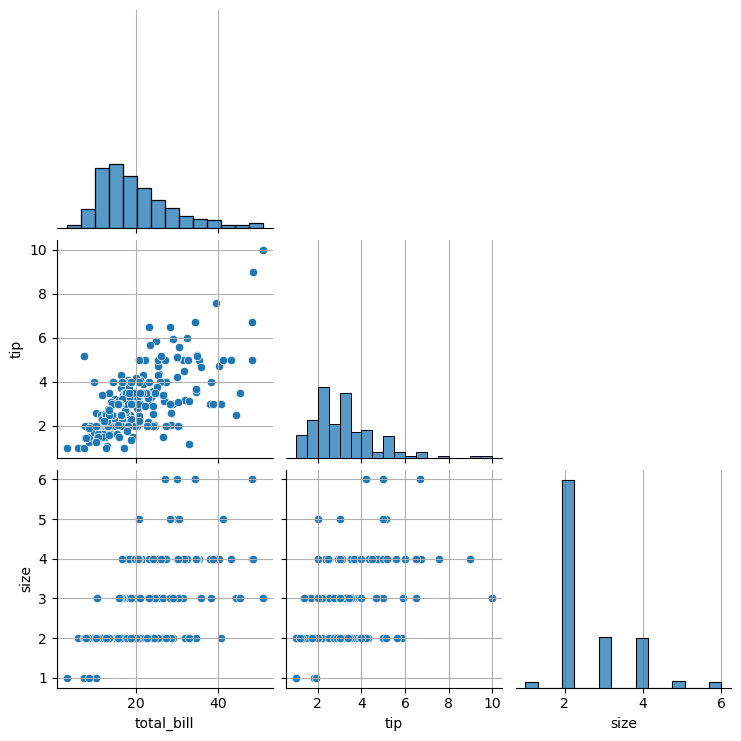

In [4]:
sns.pairplot(tips, corner=True)

## Bazinis daugialypės regresijos modelis

Kategoriniai kintamieji paverčiami į „dummy“ stulpelius. Modelis skaičiuojamas naudojant `statsmodels` OLS, nes jis pateikia diagnostikai reikalingas statistikas (rezidualus, įtaką, Cook’s D ir pan.).


In [5]:
X = tips[["total_bill", "size", "day", "time", "sex", "smoker"]].copy()
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

y = tips["tip"]

X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     26.06
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           1.20e-28
Time:                        15:43:36   Log-Likelihood:                -347.48
No. Observations:                 244   AIC:                             713.0
Df Residuals:                     235   BIC:                             744.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.5908      0.256      2.310      0.022       0.087       1.095
total_bill      0.0945      0.010      9.841      0.000       0.076       0.113
size            0.1760      0.090      1.966      0.051      -0.000       0.352
day_Fri         0.1623      0.393      0.412      0.680      -0.613       0.937
day_Sat         0.0408      0.471      0.087      0.931      -0.886       0.968
day_Sun         0.1368      0.472      0.290      0.772      -0.793       1.066
time_Dinner    -0.0681      0.445     -0.153      0.878      -0.944       0.808
sex_Female      0.0324      0.142      0.229      0.819      -0.247       0.311
smoker_No       0.0864      0.147      0.589      0.556      -0.202       0.375
==============================================================================
Omnibus:                       27.860   Durbin-Watson:                   2.096
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               52.555
Skew:                           0.607   Prob(JB):                     3.87e-12
Kurtosis:                       4.923   Cond. No.                         281.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Koeficientų interpretacija (paprasta logika)

Jei `total_bill` koeficientas yra, pavyzdžiui, 0.10, tuomet (laikant kitus kintamuosius pastoviais) `total_bill` padidėjimas 1 vienetu siejamas su `tip` padidėjimu ~0.10 vieneto.

Dažnos klaidos:
- koeficientų interpretacija be „ceteris paribus“ (neįvertinant, kad kiti kintamieji laikomi pastoviais);
- klaidinga išvada, kad koeficientas reiškia priežastį (regresija rodo asociaciją, ne priežastingumą).


### Modelio rezultatų interpretacija

Modelis paaiškina apie 47 % arbatpinigių (`tip`) variacijos (R² = 0.47). Elgsenos duomenims tai yra įprastas ir pakankamas paaiškinamumo lygis. F-statistikos p reikšmė yra mažesnė nei 0.001, todėl modelis kaip visuma yra statistiškai reikšmingas.

Svarbiausias modelio kintamasis yra `total_bill`. Jo koeficientas lygus 0.0945 ir yra statistiškai reikšmingas. Tai reiškia, kad padidėjus sąskaitai 1 vienetu, arbatpinigiai vidutiniškai padidėja apie 0.095 vieneto, laikant kitus kintamuosius pastoviais.

Kintamasis `size` turi teigiamą poveikį arbatpinigiams, tačiau jo p reikšmė yra ribinė (p ≈ 0.05). Tai leidžia manyti, kad didesnės grupės gali būti linkusios palikti daugiau arbatpinigių, tačiau šis efektas nėra stabilus.

Kategoriniai kintamieji (`day`, `time`, `sex`, `smoker`) neturi statistiškai reikšmingo poveikio arbatpinigiams, kai jau įvertinta sąskaitos suma. Tai rodo, kad diena, paros laikas, kliento lytis ar rūkymo statusas nepaaiškina papildomos `tip` variacijos.

Durbin–Watson statistika lygi 2.096, todėl rezidualų autokoreliacija neaptikta. Tai reiškia, kad rezidualų nepriklausomumo prielaida yra tenkinama.

Omnibus ir Jarque–Bera testų p reikšmės yra artimos nuliui, todėl rezidualai nėra normaliai pasiskirstę. Tai gali turėti įtakos statistinėms išvadoms, tačiau prognozavimo tikslams ši problema nėra kritinė.

Bendroji išvada: arbatpinigių dydį šiame rinkinyje beveik visiškai lemia sąskaitos suma, o kiti nagrinėti kintamieji turi labai ribotą arba nereikšmingą papildomą poveikį.


In [6]:
# Paprasta prognozė kelioms eilutėms (įvertinant visus požymius)
pred = model.predict(X_const)
pred.head()


0    2.735655
1    2.250867
2    3.259044
3    3.335332
4    3.805740
dtype: float64

### Kas yra `predict()`

`predict()` – tai metodo iškvietimas, kuris, remiantis jau apskaičiuotu regresijos modeliu, **apskaičiuoja prognozuojamas target reikšmes**.

Modelis naudoja:
- išmoktus koeficientus,
- pateiktas požymių (`X`) reikšmes,

ir grąžina **numatomą target kintamojo dydį**.

Šiame pavyzdyje:

`model.predict(X_const)`

reiškia, kad kiekvienai duomenų eilutei yra apskaičiuojama prognozuojama `tip` reikšmė, naudojant tuos pačius kintamuosius, kurie buvo panaudoti modelio sudarymui.

Gautos reikšmės yra **modelio vidutinės prognozės**, o ne tikros stebėtos reikšmės. Skirtumas tarp tikros ir prognozuotos reikšmės vadinamas **rezidualu**.

### Modelio prognozės

Žemiau pateiktos reikšmės yra modelio prognozuojami arbatpinigių (`tip`) dydžiai toms pačioms stebėjimų eilutėms, kurios buvo naudotos modelio apmokymui.

Kiekviena reikšmė reiškia prognozuojamą `tip` dydį originaliais vienetais, nes target kintamasis šiame modelyje nebuvo transformuotas.

Pavyzdžiui, prognozuojama reikšmė 2.74 reiškia, kad modelis tikisi, jog klientas paliks apie 2.74 vieneto arbatpinigių, įvertinus sąskaitos dydį, grupės dydį, dieną, laiką ir kitus požymius.

Svarbu pažymėti, kad šios prognozės rodo vidutinį tikėtiną rezultatą. Individualūs klientų sprendimai gali smarkiai nukrypti nuo modelio prognozės, todėl prognozės neturėtų būti interpretuojamos kaip tikslios atskiro kliento elgsenos reikšmės.


# Pagrindinės prielaidos ir diagnostika

Toliau pateikiami dažniausiai tikrinami punktai:
- linearity
- independence of errors
- normality of errors
- interpreting transformed targets
- no perfect multicollinearity
- equal variance of errors (homoskedastiškumas)
- outliers and influence


## 1) Linearity (tiesinis ryšys)

Prielai̇da reiškia, kad tarp target ir kiekvieno svarbaus požymio egzistuoja apytiksliai tiesinis ryšys (arba kad pasirinkta transformacija padaro ryšį „pakankamai tiesinį“).

Pažeidimo pasekmės:
- modelis negaudo tikrojo ryšio formos;
- prognozės gali būti sistemingai per didelės arba per mažos tam tikruose diapazonuose.

Diagnostika:
- scatterplot (feature prieš target)
- residual plot (rezidualai prieš prognozę)

Gerosios praktikos:
- prieš pridedant polinominius narius, pradėti nuo paprastų grafikų;
- polinomus naudoti hierarchiškai (jei yra x², paliekamas ir x).


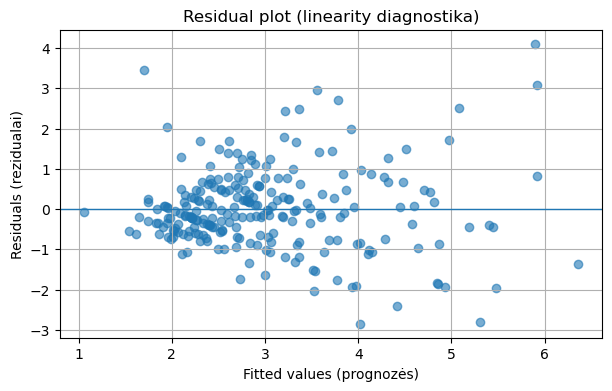

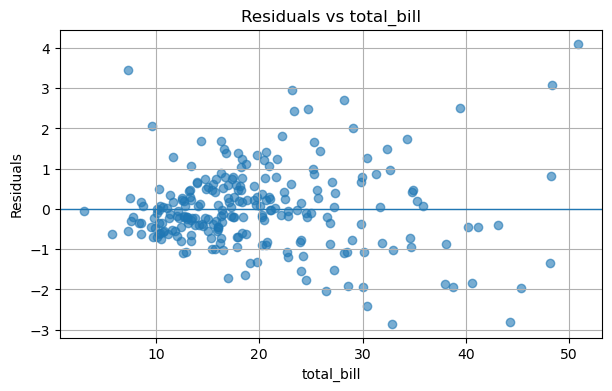

In [7]:
# Rezidualai ir prognozės
resid = model.resid
fitted = model.fittedvalues

# Residual plot: rezidualai vs prognozė
plt.figure()
plt.scatter(fitted, resid, alpha=0.6)
plt.axhline(0, linewidth=1)
plt.xlabel("Fitted values (prognozės)")
plt.ylabel("Residuals (rezidualai)")
plt.title("Residual plot (linearity diagnostika)")
plt.show()

# Papildomai: total_bill vs rezidualai (vieno požymio diagnostika)
plt.figure()
plt.scatter(tips["total_bill"], resid, alpha=0.6)
plt.axhline(0, linewidth=1)
plt.xlabel("total_bill")
plt.ylabel("Residuals")
plt.title("Residuals vs total_bill")
plt.show()


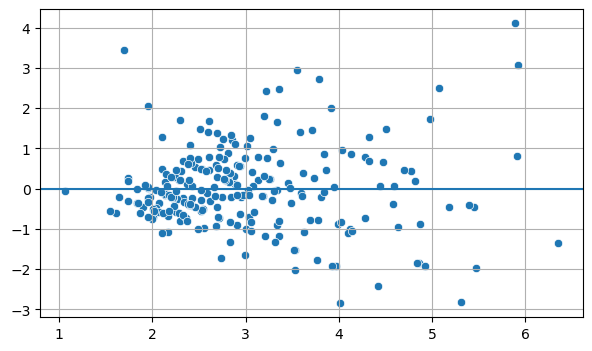

In [8]:
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(0)


model.fittedvalues – prognozės

model.resid – rezidualai

Tai yra klasikinis residual plot linearity ir equal variance diagnostikai.

### Rezidualų grafiko interpretacija

Grafike pavaizduoti rezidualai prieš prognozuotas reikšmes. Rezidualai daugiausia išsidėstę aplink nulio liniją, todėl nėra požymių, kad modelis sistemingai pervertintų arba nuvertintų prognozes. Tai leidžia manyti, kad linearity prielaida iš esmės yra tenkinama.

Aiškios kreivės ar U formos grafike nematyti, todėl nėra akivaizdaus netiesinio ryšio tarp požymių ir target.

Didėjant prognozuojamoms reikšmėms, rezidualų sklaida tampa platesnė. Tai signalizuoja galimą heteroskedastiškumą, t. y. klaidų dispersija nėra vienoda visame prognozių intervale.

Taip pat matomi pavieniai toliau nuo nulio nutolę taškai, kurie gali būti laikomi outlieriais arba įtakingais stebėjimais ir kuriuos verta papildomai patikrinti naudojant įtakos diagnostikas.

Išvada: modelis pakankamai gerai atitinka tiesiškumo prielaidą, tačiau equal variance of errors prielaida gali būti silpnai pažeista. Praktikoje verta palyginti šį grafiką su tuo pačiu grafiku po target log transformacijos.


## Netiesiškumo taisymas: polinominiai nariai

Jei ryšys akivaizdžiai kreivas, vienas paprastas sprendimas – pridėti `total_bill²`. Tai leidžia tiesiniam modeliui „nupiešti“ kreivę.

Trūkumas:
- koeficientus sunkiau aiškinti verslo kalba, nes efektas priklauso nuo `total_bill` reikšmės.


In [9]:
# Polinominis terminas: total_bill^2 (paliekant ir total_bill)
X_poly = X.copy()
X_poly["total_bill_sq"] = X_poly["total_bill"] ** 2

X_poly_const = sm.add_constant(X_poly)
model_poly = sm.OLS(y, X_poly_const).fit()

model_poly.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.450
Method:                 Least Squares   F-statistic:                     23.07
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           6.24e-28
Time:                        15:43:37   Log-Likelihood:                -347.46
No. Observations:                 244   AIC:                             714.9
Df Residuals:                     234   BIC:                             749.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.6429      0.393      1.634      0.104      -0.132       1.418
total_bill        0.0891      0.032      2.742      0.007       0.025       0.153
size              0.1775      0.090      1.969      0.050   -6.62e-05       0.355
day_Fri           0.1581      0.395      0.400      0.689      -0.620       0.936
day_Sat           0.0359      0.472      0.076      0.939      -0.895       0.967
day_Sun           0.1335      0.473      0.282      0.778      -0.799       1.065
time_Dinner      -0.0625      0.447     -0.140      0.889      -0.943       0.818
sex_Female        0.0320      0.142      0.226      0.822      -0.248       0.312
smoker_No         0.0867      0.147      0.590      0.555      -0.203       0.376
total_bill_sq     0.0001      0.001      0.174      0.862      -0.001       0.001
==============================================================================
Omnibus:                       26.602   Durbin-Watson:                   2.101
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.849
Skew:                           0.590   Prob(JB):                     2.47e-11
Kurtosis:                       4.847   Cond. No.                     8.44e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.44e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Polinominio modelio interpretacija (`total_bill²`)

Į modelį buvo pridėtas polinominis terminas `total_bill²`, siekiant patikrinti, ar ryšys tarp sąskaitos dydžio ir arbatpinigių yra netiesinis.

Rezultatai rodo, kad:
- `total_bill` išlieka statistiškai reikšmingas ir teigiamas veiksnys.
- `total_bill_sq` nėra statistiškai reikšmingas (p reikšmė didelė), todėl papildomas netiesinis efektas neaptinkamas.
- Modelio paaiškinamoji galia (R² ≈ 0.47) praktiškai nepasikeitė, palyginti su baziniu modeliu.

Tai reiškia, kad šiame duomenų rinkinyje **tiesinis ryšys tarp sąskaitos dydžio ir arbatpinigių yra pakankamas**, o polinominis terminas neprideda papildomos informacijos.

Papildoma pastaba:
- Condition Number yra labai didelis, kas rodo stiprų koreliavimą tarp `total_bill` ir `total_bill²`. Tai yra įprasta polinominiuose modeliuose ir dar viena priežastis, kodėl tokie modeliai sunkiau interpretuojami.

Išvada: šiame pavyzdyje polinominio termino naudoti neverta, nes jis **nepagerina modelio ir apsunkina interpretaciją**.


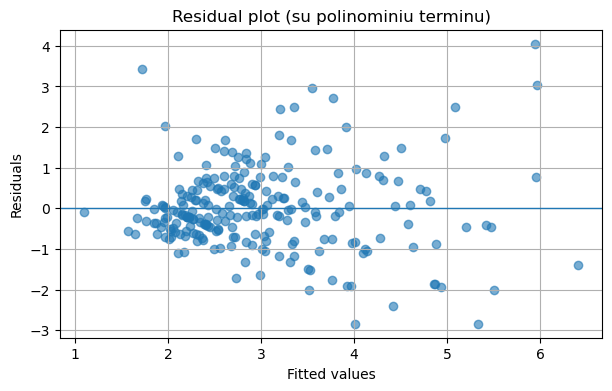

In [10]:
# Palyginimas: rezidualai vs prognozė polinominiame modelyje
resid_poly = model_poly.resid
fitted_poly = model_poly.fittedvalues

plt.figure()
plt.scatter(fitted_poly, resid_poly, alpha=0.6)
plt.axhline(0, linewidth=1)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual plot (su polinominiu terminu)")
plt.show()


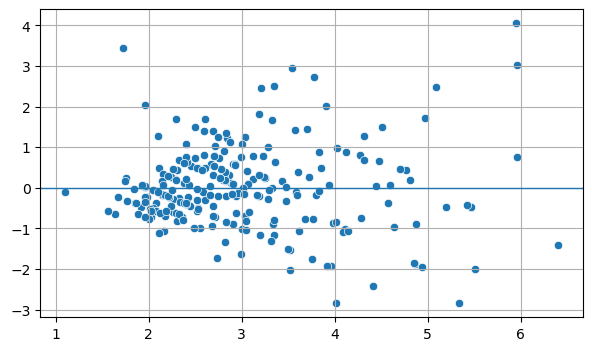

In [11]:
sns.scatterplot(x=fitted_poly, y=resid_poly)
plt.axhline(0, linewidth=1)

### Rezidualų grafikas su polinominiu terminu

Grafike pavaizduoti rezidualai prieš prognozuotas reikšmes polinominiame modelyje. Rezidualai išsidėstę aplink nulio liniją be aiškios sisteminės kreivės, todėl papildomas polinominis terminas neišsprendžia ryškios netiesiškumo problemos.

Rezidualų sklaida didėjant prognozuojamoms reikšmėms išlieka nevienoda. Tai rodo, kad heteroskedastiškumo problema nėra pašalinta, o polinominis terminas reikšmingai nepagerino equal variance of errors prielaidos.

Išvada: polinominis modelis nepateikia aiškaus diagnostinio pranašumo prieš bazinį tiesinį modelį ir papildomai apsunkina interpretaciją.


## 2) Independence of errors (rezidualų nepriklausomumas)

Prielai̇da reiškia, kad rezidualai neturi tarpusavio ryšių (nėra autokoreliacijos). Dažniausia rizika – kai duomenys yra laiko eilutė (pvz., mėnesiniai pardavimai) ir klaidos „tempiasi“ per laiką.

Diagnostika:
- Durbin–Watson statistika (DW)
  - H0: DW = 2 (nėra autokoreliacijos)
  - H1: DW ≠ 2 (yra autokoreliacija)
  - praktinė taisyklė: ~1.5–2.5 dažnai laikoma priimtina

Dažna klaida:
- tikrinti DW, kai duomenys surikiuoti pagal target ar kitą svarbų kintamąjį; tvarka gali dirbtinai sukurti raštus.


In [12]:
# Durbin–Watson (baziniam modeliui)
dw = durbin_watson(resid)
dw


2.096102793525324

In [13]:
# Pavyzdys: surikiavimas pagal target gali sukurti dirbtinę problemą
tips_sorted = tips.sort_values("tip").copy()

X_s = tips_sorted[["total_bill", "size", "day", "time", "sex", "smoker"]]
X_s = pd.get_dummies(X_s, drop_first=True).astype(float)
y_s = tips_sorted["tip"].astype(float)

model_s = sm.OLS(y_s, sm.add_constant(X_s)).fit()
dw_sorted = durbin_watson(model_s.resid)

# Taisymas: eilučių sumaišymas (nekeičiant reikšmių)
tips_shuffled = tips_sorted.sample(frac=1, random_state=42).copy()

X_sh = tips_shuffled[["total_bill", "size", "day", "time", "sex", "smoker"]]
X_sh = pd.get_dummies(X_sh, drop_first=True).astype(float)
y_sh = tips_shuffled["tip"].astype(float)

model_sh = sm.OLS(y_sh, sm.add_constant(X_sh)).fit()
dw_shuffled = durbin_watson(model_sh.resid)

dw_sorted, dw_shuffled


(0.8549963870411089, 2.0888583694063674)

### Durbin–Watson rezultatų interpretacija

Gautos dvi Durbin–Watson (DW) statistikos reikšmės atitinka du skirtingus duomenų paruošimo scenarijus.

Pirmoji reikšmė (DW ≈ 0.85) gauta tada, kai duomenys buvo surikiuoti pagal `tip`. Tokia maža reikšmė rodo stiprią teigiamą autokoreliaciją rezidualuose, t. y. klaidos nėra nepriklausomos ir „tempiasi“ viena po kitos. Šiuo atveju tai nėra reali modelio problema, o dirbtinis efektas, atsiradęs dėl netinkamos eilučių tvarkos.

Antroji reikšmė (DW ≈ 2.09) gauta po to, kai duomenų eilutės buvo atsitiktinai sumaišytos. Reikšmė yra arti 2, todėl rezidualų autokoreliacija neaptinkama ir independence of errors prielaida laikoma tenkinama.

Išvada: neteisingas duomenų surikiavimas gali sukelti klaidingą įspūdį, kad modelis pažeidžia prielaidas. Prieš atliekant diagnostiką, duomenų tvarka turi būti atsitiktinė, nebent sąmoningai analizuojama laiko eilutė.
``


## 3) Normality of errors (rezidualų normalumas)

Prielai̇da reiškia, kad rezidualai yra apytiksliai normaliai pasiskirstę. Tai ypač svarbu inference tikslams (p reikšmėms ir pasikliautiniams intervalams). Prognozėms ši prielaida dažnai nėra kritinė, jei klaidos yra pakankamai mažos ir be sisteminių raštų.

Diagnostika:
- QQ plot (quantile–quantile grafikas)
- histograma (papildomai, kaip pagalbinė vizualizacija)

Dažna klaida:
- normalumo tikrinimas ant target, o ne ant rezidualų.


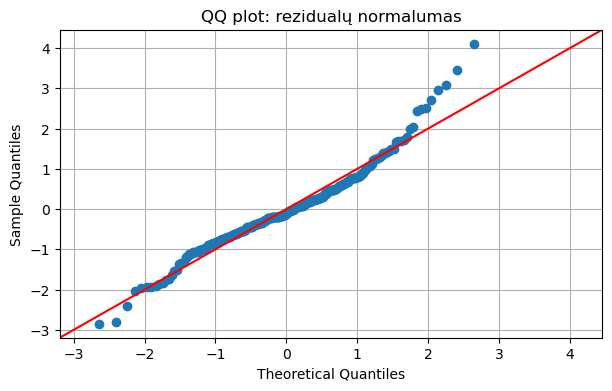

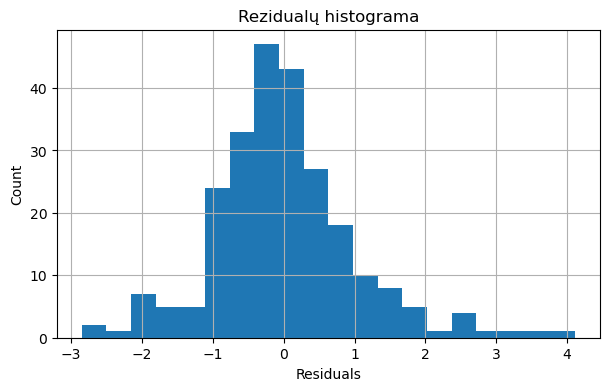

In [14]:
# QQ plot rezidualams
sm.qqplot(resid, line="45")
plt.title("QQ plot: rezidualų normalumas")
plt.show()

# Histograma (papildomai)
plt.figure()
plt.hist(resid, bins=20)
plt.title("Rezidualų histograma")
plt.xlabel("Residuals")
plt.ylabel("Count")
plt.show()


### Rezidualų normalumo diagnostika

QQ grafike dauguma taškų išsidėstę arti įstrižinės linijos, todėl rezidualų pasiskirstymas yra artimas normaliam. Tačiau kraštuose matomi nukrypimai, rodantys sunkesnes uodegas ir pavienius ekstremalius stebėjimus.

Rezidualų histograma rodo apytiksliai varpo formos pasiskirstymą, tačiau matomas nedidelis asimetriškumas ir ilgesnė dešinė uodega.

Išvada: normality of errors prielaida iš esmės yra priimtina praktinei analizei, tačiau nėra idealiai tenkinama. Tai gali turėti įtakos statistinėms išvadoms, bet prognozavimo tikslams ši problema nėra kritinė.


## 4) Transformuoto target interpretavimas (log transformacija)

Log transformacija dažnai naudojama, kai:
- target pasiskirstymas yra labai asimetriškas (didelė „uodega“);
- rezidualų sklaida didėja didėjant target (heteroskedastiškumas);
- norima interpretuoti efektus procentais (multiplikatyvus ryšys).

Svarbu:
- transformavus target, koeficientai keičia prasmę;
- prognozes reikia grąžinti į pradinius vienetus invertuojant transformaciją.


In [15]:
# Log transformacija target: log(tip)
# Naudojamas log1p, kad išvengtų problemų su 0 (čia tip>0, bet tai geras įprotis)
y_log = np.log(tips["tip"])

model_log = sm.OLS(y_log, X_const).fit()
model_log.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    tip   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     23.47
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.80e-26
Time:                        15:43:38   Log-Likelihood:                -71.628
No. Observations:                 244   AIC:                             161.3
Df Residuals:                     235   BIC:                             192.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.2668      0.083      3.230      0.001       0.104       0.430
total_bill      0.0283      0.003      9.140      0.000       0.022       0.034
size            0.0581      0.029      2.011      0.045       0.001       0.115
day_Fri         0.0532      0.127      0.419      0.676      -0.197       0.303
day_Sat        -0.0155      0.152     -0.102      0.919      -0.315       0.284
day_Sun         0.0629      0.152      0.413      0.680      -0.237       0.363
time_Dinner    -0.0139      0.144     -0.097      0.923      -0.297       0.269
sex_Female      0.0181      0.046      0.396      0.693      -0.072       0.108
smoker_No       0.0180      0.047      0.380      0.704      -0.075       0.111
==============================================================================
Omnibus:                        4.024   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.134   Jarque-Bera (JB):                3.685
Skew:                          -0.251   Prob(JB):                        0.158
Kurtosis:                       3.332   Cond. No.                         281.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Koeficiento interpretacija su log(target)

Jei modelis yra `log(tip) = ... + β * total_bill + ...`, tuomet `β` apytiksliai reiškia procentinį pokytį:

- apie `100 * (exp(β) - 1)` procentų target pokyčio, kai `total_bill` padidėja 1 vienetu (laikant kitus kintamuosius pastoviais).

Tai yra multiplikatyvi interpretacija (procentais), o ne absoliutus pokytis.


### `total_bill` koeficiento interpretacija log(target) modelyje

Modelyje naudojamas logaritmiškai transformuotas target (`log(tip)`), todėl koeficientai interpretuojami **procentiniais pokyčiais**, o ne absoliučiomis sumomis.

Gauta:
- `beta = 0.0283`
- procentinė interpretacija ≈ **2.87 %**

Tai reiškia, kad **padidėjus sąskaitai (`total_bill`) 1 vienetu, arbatpinigių dydis vidutiniškai padidėja apie 2.9 %**, laikant kitus kintamuosius pastoviais.

Svarbu pabrėžti:
- tai yra **vidutinis procentinis pokytis**, ne garantuotas rezultatas kiekvienam klientui;
- interpretacija yra **multiplikatyvi**, todėl poveikis didesnėms sąskaitoms absoliučiai bus didesnis nei mažoms.

Išvada: log(target) modelis leidžia aiškiai ir verslo prasme interpretuoti ryšį kaip „procentinį augimą“, o ne kaip fiksuotą arbatpinigių sumos pokytį.


In [16]:
# Pavyzdys: total_bill koeficientas log(target) modelyje ir jo interpretacija procentais
beta = model_log.params.get("total_bill", np.nan)
pct = 100 * (np.exp(beta) - 1)

beta, pct

(0.028331716057627607, 2.8736876369837905)

### Modelio su log(target) rezultatų interpretacija

Šiame modelyje buvo naudojamas logaritmiškai transformuotas target kintamasis (`log(tip)`). Modelis paaiškina apie 44 % transformuoto `tip` variacijos (R² = 0.444), o F-statistikos p reikšmė yra mažesnė nei 0.001, todėl modelis kaip visuma yra statistiškai reikšmingas.

Kintamasis `total_bill` yra statistiškai reikšmingas ir turi teigiamą poveikį. Tai reiškia, kad didėjant sąskaitos dydžiui, arbatpinigiai auga procentiškai. Pagal koeficientą galima teigti, kad padidinus `total_bill` vienetu, `tip` padidėja maždaug keliais procentais, laikant kitus kintamuosius pastoviais.

Kintamasis `size` taip pat yra statistiškai reikšmingas, nors jo poveikis silpnesnis. Didesnės klientų grupės yra linkusios palikti šiek tiek daugiau arbatpinigių procentine išraiška.

Kiti kintamieji (`day`, `time`, `sex`, `smoker`) nėra statistiškai reikšmingi. Tai rodo, kad įvertinus sąskaitos dydį ir grupės dydį, diena, paros laikas, lytis ar rūkymo statusas neturi papildomo poveikio arbatpinigiams.

Durbin–Watson statistika yra arti 2, todėl rezidualų autokoreliacija neaptinkama. Omnibus ir Jarque–Bera testų p reikšmės yra didesnės nei 0.05, todėl rezidualų normalumo prielaida šiame modelyje yra žymiai geriau tenkinama nei baziniame modelyje.

Išvada: log(target) transformacija pagerino rezidualų normalumą ir stabilizavo modelio elgseną, tuo pačiu išlaikydama prasmingą ir interpretuojamą ryšį tarp sąskaitos dydžio ir arbatpinigių.


## Prognozės grąžinimas į pradinius vienetus

Modelis prognozuoja `log(tip)`. Norint gauti `tip` eurais, taikoma `exp()`.

Dažna klaida:
- palyginti log skalės prognozes su originaliais `tip` vienetais (tai yra skirtingos skalės).


In [17]:
# Prognozė log skalėje ir invertavimas į pradinius vienetus
pred_log = model_log.predict(X_const)
pred_tip = np.exp(pred_log)

pd.DataFrame({
    "tip_actual": tips["tip"].head(5).values,
    "pred_log": pred_log.head(5).values,
    "pred_tip_inverted": pred_tip.head(5).values
})


,tip_actual,pred_log,pred_tip_inverted
0,1.01,0.949534,2.584505
1,1.66,0.801163,2.228130
2,3.50,1.103462,3.014585
3,3.31,1.120973,3.067837
4,3.61,1.281125,3.600689


### Prognozių interpretacija po log(target) transformacijos

Modelis pateikia prognozes logaritminėje skalėje (`pred_log`), todėl šios reikšmės nėra tiesiogiai interpretuojamos verslo kontekste. Norint gauti prognozes pradiniais vienetais, taikomas atvirkštinis veiksmas – eksponentė (`exp()`), kuri grąžina `pred_tip_inverted`.

Lentelėje:
- `tip_actual` rodo faktinius stebėtus arbatpinigius;
- `pred_log` rodo modelio prognozes log skalėje;
- `pred_tip_inverted` rodo prognozuotus arbatpinigius pradiniais vienetais.

Palyginus faktines ir prognozuotas reikšmes matyti, kad modelis pateikia **vidutines tendencijas**, o ne tikslias individualias reikšmes. Kai kuriais atvejais prognozės yra didesnės arba mažesnės už faktines reikšmes, kas yra normalu regresijos modeliams.

Išvada: dirbant su log(target) modeliais, prognozes visada būtina grąžinti į pradinius vienetus prieš interpretuojant rezultatus verslo prasme.


# 5) No perfect multicollinearity (multikolinerumas)

Prielai̇da reiškia, kad požymiai nėra (beveik) tų pačių signalų kopijos. Stiprus multikolinerumas daro koeficientus nestabilius: jie gali keisti ženklą, o p reikšmės tampa nepatikimos.

Diagnostika:
- VIF (Variance Inflation Factor)
  - praktinė taisyklė: VIF > 5 dažnai laikomas problema

Gerosios praktikos:
- su dummy kintamaisiais naudoti `drop_first=True` (arba aiškiai pasirinkti bazinę kategoriją);
- vengti vienu metu dėti „sudėtinius“ ir „jų komponentus“ (pvz., `Revenue` ir `Price` su `Quantity`, jei `Revenue = Price * Quantity`).


In [18]:
# VIF skaičiavimas (be konstanta stulpelio)
X_for_vif = X.copy()

vif_df = pd.DataFrame({
    "feature": X_for_vif.columns,
    "VIF": [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df


,feature,VIF
5,time_Dinner,33.150259
3,day_Sat,17.730443
4,day_Sun,15.810322
1,size,12.048233
0,total_bill,9.443197
7,smoker_No,2.635550
2,day_Fri,2.559699
6,sex_Female,1.479481


### Multikolinerumo diagnostika naudojant VIF

Lentelėje pateiktos VIF (Variance Inflation Factor) reikšmės kiekvienam modelio požymiui. VIF parodo, **kiek stipriai konkretus kintamasis gali būti paaiškintas kitais modelio kintamaisiais**.

Praktinė interpretacija:
- **VIF ≈ 1–2** – multikolinerumo problema neegzistuoja.
- **VIF > 5** – galimos multikolinerumo problemos.
- **VIF > 10** – stiprus multikolinerumas, koeficientai tampa nestabilūs.

Šiame rezultate:
- `time_Dinner`, `day_Sat`, `day_Sun`, `size` ir `total_bill` turi **aukštas VIF reikšmes**, rodančias stiprų tarpusavio ryšį.
- Tai reiškia, kad šie kintamieji dalinasi panašia informacija (pvz., vakarienė dažniau vyksta savaitgaliais ir su didesnėmis grupėmis).
- Tokia situacija gali sukelti nestabilius koeficientus ir nepatikimas p reikšmes, nors prognozės gali išlikti geros.

Kiti kintamieji (`sex_Female`, `day_Fri`, `smoker_No`) turi mažas VIF reikšmes ir multikolinerumo problemų nekelia.

Išvada: modelyje egzistuoja **reikšmingas multikolinerumas**, todėl šis modelis labiau tinkamas prognozėms nei tiksliam atskirų koeficientų interpretavimui. Jei tikslas yra inference, verta apsvarstyti požymių šalinimą arba jų sujungimą į prasmingesnius rodiklius.


### Multikolinerumo taisymas (bazinis požiūris)

Dažniausi sprendimai:
- pašalinti feature’us su dideliu VIF (paliekant bent vieną iš grupės, kad išliktų interpretacija);
- sukurti kombinuotą rodiklį (pvz., vietoje dviejų stipriai susijusių – vienas prasmingas santykis);
- naudoti regularizaciją (Ridge / Lasso), jei prioritetas yra stabilumas.


## 6) Equal variance of errors (homoskedastiškumas)

Prielai̇da reiškia, kad rezidualų sklaida (paklaidos dydis) yra panaši visame prognozių intervale. Jei sklaida didėja didėjant prognozei, tai heteroskedastiškumas.

Diagnostika:
- residual plot (rezidualai vs fitted)
  - „vėduoklės“ / kūgio forma signalizuoja heteroskedastiškumą

Dažna praktinė pastaba:
- inference atveju heteroskedastiškumas kenkia pasikliautiniams intervalams;
- prognozėms jis kartais toleruojamas, bet verta žinoti, kur modelis klysta labiau.


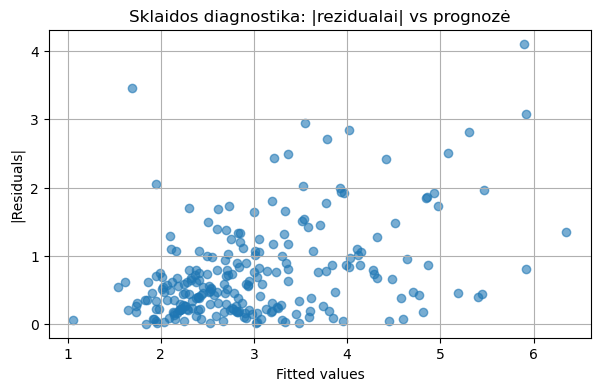

In [19]:
# Residual plot jau buvo pavaizduotas; čia papildomai įvertinamas absoliutus rezidualas prieš prognozę
plt.figure()
plt.scatter(fitted, np.abs(resid), alpha=0.6)
plt.xlabel("Fitted values")
plt.ylabel("|Residuals|")
plt.title("Sklaidos diagnostika: |rezidualai| vs prognozė")
plt.show()


<Axes: >

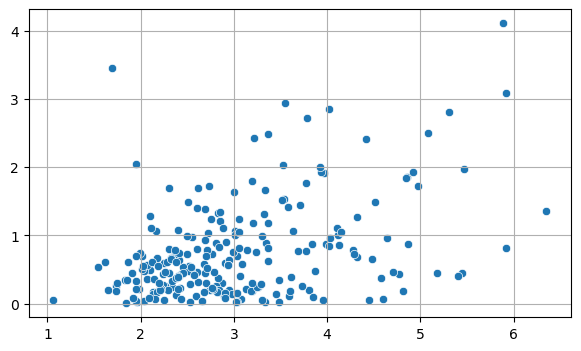

In [20]:
sns.scatterplot(x=fitted, y=np.abs(resid))

### Sklaidos (heteroskedastiškumo) diagnostika

Grafike pavaizduotas absoliutus rezidualų dydis prieš prognozuotas reikšmes. Matyti, kad didėjant prognozuojamoms reikšmėms, rezidualų dydis linkęs didėti.

Tai rodo **heteroskedastiškumą**, t. y. klaidų dispersija nėra vienoda visame prognozių intervale. Modelis klysta labiau didesnių prognozių atveju nei mažesnių.

Išvada: equal variance of errors prielaida yra pažeista. Praktinis sprendimas – taikyti logaritminę transformaciją target kintamajam arba naudoti modelius, atsparesnius nevienodai sklaidai.


### Heteroskedastiškumo taisymas

Dažnas sprendimas – log transformacija target, nes ji stabilizuoja sklaidą. Praktikoje verta palyginti residual plot prieš ir po transformacijos.


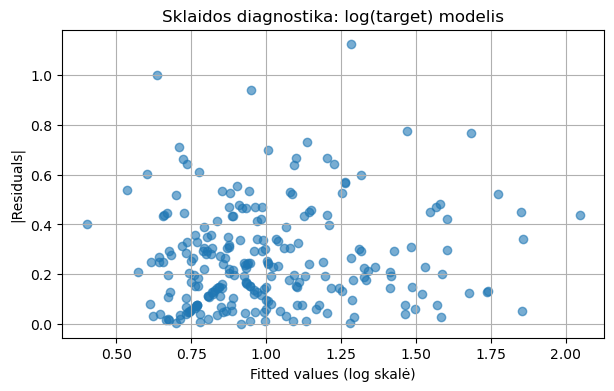

In [21]:
# Palyginimas: |rezidualai| prieš prognozę log(target) modelyje
resid_log = model_log.resid
fitted_log = model_log.fittedvalues

plt.figure()
plt.scatter(fitted_log, np.abs(resid_log), alpha=0.6)
plt.xlabel("Fitted values (log skalė)")
plt.ylabel("|Residuals|")
plt.title("Sklaidos diagnostika: log(target) modelis")
plt.show()


<Axes: >

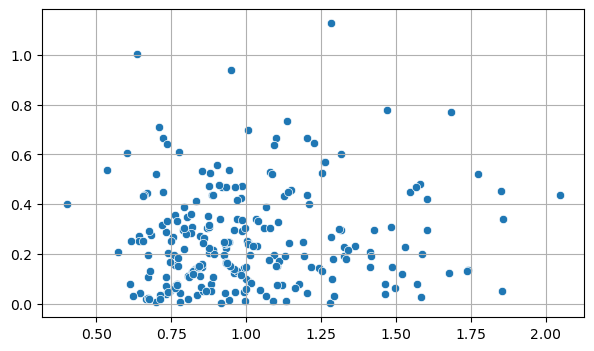

In [22]:
sns.scatterplot(x=fitted_log, y=np.abs(resid_log))

### Sklaidos diagnostika log(target) modelyje

Grafike pavaizduotas absoliutus rezidualų dydis prieš prognozuotas reikšmes logaritminėje skalėje. Lyginant su modeliu be transformacijos, rezidualų sklaida yra tolygesnė visame prognozių intervale.

Nebematoma aiškios „vėduoklės“ formos, kuri būdinga heteroskedastiškumui. Tai rodo, kad log(target) transformacija **stabilizavo klaidų dispersiją** ir pagerino equal variance of errors prielaidos tenkinimą.

Pavienių didesnių rezidualų vis dar pasitaiko, tačiau jie nebėra sistemiškai susiję su prognozės dydžiu.

Išvada: log(target) modelis pasižymi tolygesne klaidų sklaida ir yra stabilesnis tiek interpretacijai, tiek prognozėms.


## 7) Outliers ir influence (įtakingi taškai)

Outlier yra neįprasta reikšmė, bet ne kiekvienas outlier yra problema. Svarbiausi yra įtakingi taškai (influential points), kurie smarkiai keičia regresijos liniją ir koeficientus.

Diagnostika:
- Cook’s Distance (Cook’s D)
  - praktinė taisyklė: Cook’s D > 0.5 verta tirti, Cook’s D > 1 dažnai laikoma rimta problema

Gerosios praktikos:
- patikrinti, ar taškas nėra duomenų klaida;
- palyginti modelį „su“ ir „be“ įtakingų taškų;
- jei tai realus verslo atvejis, dažnai geriau sukurti papildomą feature, kuris paaiškina situaciją (pvz., „akcija“, „šventinė diena“, „VIP klientas“).


In [23]:
# Įtakos statistikos
infl = model.get_influence()
infl_df = infl.summary_frame()

# Pagrindiniai stulpeliai: cooks_d, hat_diag (leverage), student_resid
infl_df[["cooks_d", "hat_diag", "student_resid"]].head()


,cooks_d,hat_diag,student_resid
0,0.009650,0.028855,-1.716746
1,0.001061,0.027165,-0.584067
2,0.000099,0.015578,0.236633
3,0.000002,0.024386,-0.024987
4,0.000140,0.032281,-0.193873


### Įtakos (influence) statistikos išgavimas

`get_influence()` yra **modelio metodo iškvietimas**, kuris apskaičiuoja įtakos (influence) diagnostikas kiekvienam stebėjimui.

`summary_frame()` yra **metodas**, taikomas `get_influence()` grąžintam objektui, kuris pateikia šias diagnostikas patogios lentelės (DataFrame) pavidalu.

Trumpai:
- `get_influence()` → apskaičiuoja įtakos rodiklius  
- `summary_frame()` → pateikia juos lentelėje analizei

- **Cook’s Distance** – parodo, ar taškas stipriai keičia modelio koeficientus;
- **leverage (hat_diag)** – parodo, ar stebėjimas turi neįprastas požymių reikšmes;
- **studentizuoti rezidualai** – padeda aptikti ekstremalias paklaidas.

Šios statistikos naudojamos identifikuoti **outlierius ir įtakingus taškus**, kurie gali iškreipti modelio interpretaciją ir prognozes.

### Įtakos diagnostikų interpretacija

Pagrindiniai rodikliai, skirti įvertinti, ar konkretūs stebėjimai daro neproporcingai didelę įtaką regresijos modeliui.

`cooks_d` parodo, kiek vieno stebėjimo pašalinimas pakeistų regresijos koeficientus. Labai mažos reikšmės (arti 0) reiškia, kad šie taškai modelio stipriai neveikia.

`hat_diag` (leverage) parodo, ar stebėjimas turi neįprastas požymių reikšmes. Čia pateiktos reikšmės yra nedidelės, todėl šie stebėjimai neturi didelio sverto modelyje.

`student_resid` rodo rezidualą, įvertintą atsižvelgiant į jo dispersiją. Reikšmės tarp −2 ir 2 laikomos įprastomis, todėl šie stebėjimai nėra laikomi probleminiais outlieriais.

Išvada: pateikti stebėjimai nėra įtakingi, nekelia problemų regresijos stabilumui ir neturi reikšmingos įtakos modelio rezultatams.


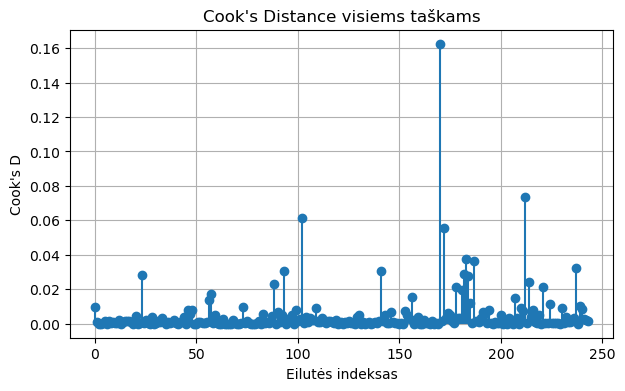

In [24]:
# Cook's D vizualizacija
cooks_d = infl_df["cooks_d"].values

plt.figure()
plt.stem(np.arange(len(cooks_d)), cooks_d, basefmt=" ")
plt.title("Cook's Distance visiems taškams")
plt.xlabel("Eilutės indeksas")
plt.ylabel("Cook's D")
plt.show()


### Cook’s Distance grafiko interpretacija

Grafike pavaizduota **Cook’s Distance reikšmė kiekvienam stebėjimui**. Dauguma taškų turi labai mažas reikšmes, artimas nuliui, todėl **didžioji dalis stebėjimų neturi reikšmingos įtakos modeliui**.

Matomi keli ryškesni „spygliai“, t. y. stebėjimai su didesne Cook’s D reikšme. Tai **potencialiai įtakingi taškai**, kurie labiau nei kiti keičia regresijos koeficientus.

Svarbu pažymėti, kad:
- nė vienas taškas neviršija ribos **Cook’s D > 1**, todėl rimtos problemos nėra;
- keli taškai virš **0.5 nėra**, tad tai greičiau signalai patikrinimui, o ne būtinybė šalinti duomenis.

Išvada: modelis nėra valdomas pavienių stebėjimų. Keli taškai gali turėti didesnę įtaką, tačiau jie nekelia kritinės grėsmės modelio stabilumui ir turėtų būti vertinami verslo kontekste.


In [25]:

# Didžiausi įtakingi taškai
top = infl_df.sort_values("cooks_d", ascending=False).head(10)[["cooks_d", "hat_diag", "student_resid"]]
top


,cooks_d,hat_diag,student_resid
170,0.162552,0.077421,4.330156
212,0.073750,0.064285,3.167443
102,0.061543,0.064425,-2.879783
172,0.055534,0.040475,3.524857
183,0.037456,0.037700,2.982241
187,0.036478,0.052864,-2.451009
237,0.032246,0.034968,-2.873422
93,0.030727,0.085156,1.730959
141,0.030365,0.081243,1.765898
182,0.028958,0.061851,-2.000922


### Įtakingų stebėjimų interpretacija
Šie i stebėjimai turi didžiausias **Cook’s Distance** reikšmes visame duomenų rinkinyje, todėl jie laikomi **potencialiai įtakingais taškais**.

`cooks_d` parodo, kiek stipriai konkretus stebėjimas veikia regresijos koeficientus. Reikšmės šiame sąraše yra didesnės nei daugumos kitų taškų, tačiau vis dar mažesnės nei kritinė riba (Cook’s D > 1), todėl tai nėra ekstremalios problemos, bet signalai detalesniam vertinimui.

`hat_diag` rodo stebėjimo svertą (leverage). Santykinai didesnės reikšmės reiškia, kad šie taškai turi neįprastas požymių kombinacijas, kurios gali stipriau paveikti modelį.

`student_resid` pateikia standartizuotus rezidualus. Reikšmės, kurių absoliutinė vertė viršija 2 arba 3, rodo neįprastas paklaidas ir leidžia laikyti šiuos stebėjimus galimais outlieriais pagal target.

Išvada: šie stebėjimai nėra kritiškai problemiški, tačiau jie turi didesnę įtaką nei kiti ir turėtų būti analizuojami atskirai, siekiant nustatyti, ar tai realūs verslo atvejai, ar galimos duomenų klaidos.


# Kaip elgtis su įtakingais taškais (bazinis sprendimų sąrašas)

- Palikti: jei tai tikras ir svarbus verslo scenarijus, kurį reikia prognozuoti.
- Pašalinti: jei tai aiški įvedimo klaida, dublis ar nereprezentatyvus įvykis, kurio neplanuojama modeliuoti.
- Paaiškinti feature’ais: sukurti požymį, kuris atskiria kontekstą (pvz., „didelė grupė“, „ypatinga diena“, „nuolaida“).
- Naudoti robust regression: kai norima sumažinti ekstremalių taškų įtaką, bet implementacija gali būti atidėta vėlesniam etapui.


# Santrauka ir dažnos klaidos

Dažniausiai pasitaikantys netikslumai praktikoje:
- prielaidų netikrinimas, kai modelis naudojamas koeficientų interpretacijai;
- linearity tikrinimas tik pagal R² (aukštas R² nereiškia teisingos formos);
- normalumo tikrinimas target vietoje rezidualų;
- dummy kintamųjų įvedimas be bazinės kategorijos (sukuriant pilną kolinearumą);
- sprendimas „išmesti outlierius“ nepatikrinus, ar tai realus verslo atvejis.

Gerosios praktikos trumpai:
- pradėti nuo grafinių diagnostikų (scatterplot, residual plot, QQ);
- naudoti VIF koeficientų stabilumui;
- aiškiai suprasti, ar tikslas yra inference ar prediction;
- transformacijas taikyti atsargiai ir visada grąžinti prognozes į pradinius vienetus, kai reikia verslo interpretacijos.
